#### Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint # Biblioteca pronta para resolver equações diferenciais.

#### Método de Runge-Kutta 4° Ordem - RK4

In [2]:
def  RK4(modelo, t_0, t_final, y0, h, parametros):
    t = np.arange(t_0, t_final + h, h )
    y = np.zeros((len(t) , len(y0)))
    y[0] = y0

    for i in range(1, len(t)):
        k1 = h*modelo(t[i-1], y[i-1], * parametros)
        k2 = h*modelo(t[i-1] + h/2, y[i-1] + k1/2, * parametros)
        k3 = h*modelo(t[i-1] + h/2, y[i-1] + k2/2, * parametros)
        k4 = h*modelo(t[i-1] + h, y[i-1] + k3, * parametros)

        y[i] = y[i-1] + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y 

### Modelo SIR Simples

*   Equação dos individuos **Suscetíveis**
$$\dfrac{dS}{dt} = -\beta SI$$

*   Equação dos individuos **Infecctados**
$$\dfrac{dI}{dt} = -\beta SI - \gamma I$$

*   Equação dos individuos **Recuperados**
$$\dfrac{dR}{dt} = \gamma I$$

In [3]:
def Modelo_SIR(t, y, beta, gamma):
    S, I, R = y

    dS = -beta*S*I

    dI = beta*S*I - gamma*I

    dR = gamma*I
    
    return np.array([dS, dI, dR])

### Informações de Modelo

- Valores dos parâmetros
- Condições iniciais
- Intervalo de Tempo
- Espaçamento

#### Parâmetro do Modelo

* $\beta:$ Taxa de **Infecção**
* $\gamma$ Taxa de **Recuperação**

In [4]:
# Parâmetros
beta = 0.3
gamma = 0.1

#### Condições Iniciais $S_0, I_0$ e $R_0$

In [5]:
# Quantidade total da população
N = 1000

# Condições Inicias
S0 = 999/N
I0 = 7/N
R0 = 0.0

y0 = np.array([S0, I0, R0])

#### Intervalo de Tempo de Simulação e o Espaçamento do Tempo

In [6]:
# Definindo o Intervalo de Tempo [t_0, t_f]
t0 = 0
t_final = 180

# Espaçamento
h = 0.01

#### Chamando o Método de RK4

In [7]:
parametros = (beta, gamma)
t, y = RK4(Modelo_SIR, t0, t_final, y0, h, parametros)


#### Gráfico da Dinâmica Populacional

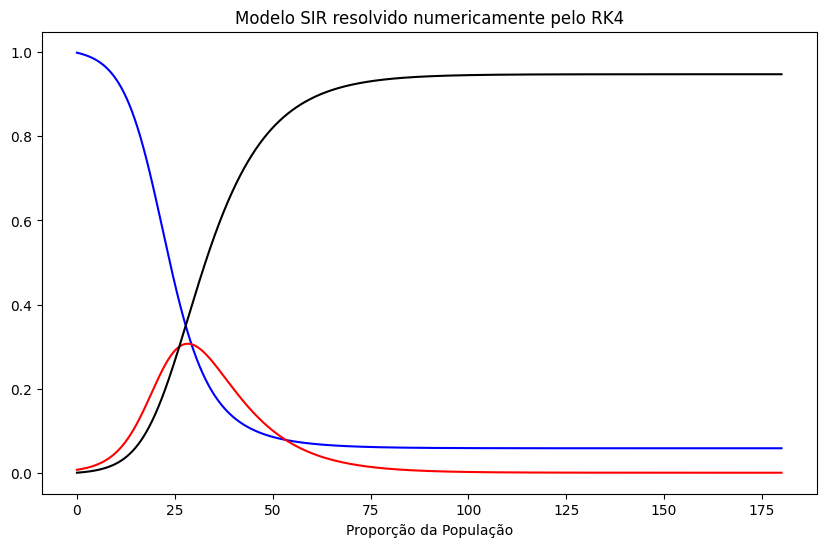

In [8]:
plt.figure(figsize = (10, 6))
plt.plot(t , y[: , 0], label = 'Suscetível - S', color = 'blue')
plt.plot(t , y[: , 1], label = 'Infectados - I', color = 'red')
plt.plot(t , y[: , 2], label = 'Recuperados - R', color = 'black')

plt.title('Modelo SIR resolvido numericamente pelo RK4')
plt.xlabel('Tempo (dias)')
plt.xlabel('Proporção da População')
plt.legend

plt.show()

#### Número Reprodutivo Básico - $\mathcal{R}_0$

In [9]:
# Fixar os Parâmetros
betaFixo = 0.3
gammaFixo = 0.1

betaValores = np.linspace(0.1, 1.0, 10)
gammaValores = np.linspace(0.1, 1.0, 10)

R_0beta = betaValores/gammaFixo
R_0gamma = betaFixo / gammaValores

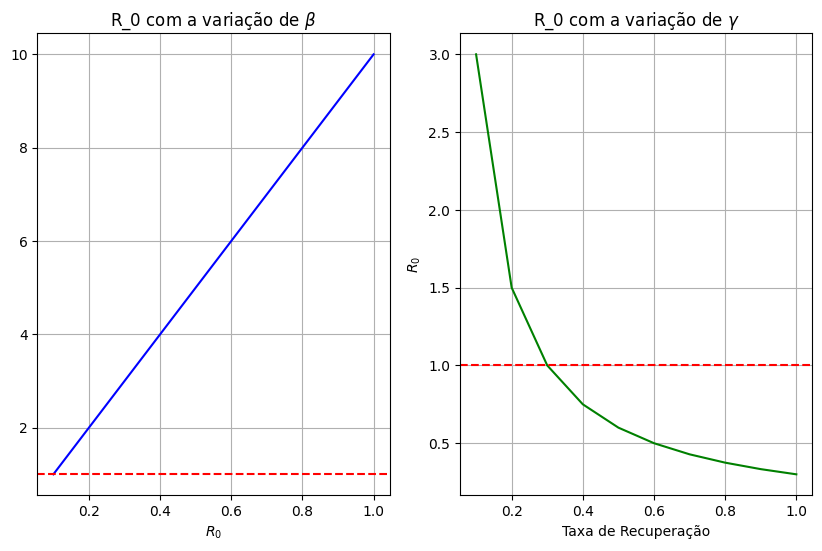

In [10]:
# 
plt.figure(figsize = (10, 6))

#Variação de Beta
plt.subplot(1, 2, 1)
plt.plot(betaValores, R_0beta, color = 'blue')
plt.axhline(1, color = 'red', linestyle = '--')
plt.title('R_0 com a variação de $\\beta$')
plt.xlabel('Taxa de Transmissão')
plt.xlabel('$R_0$')
plt.grid()

#Variação de Gamma
plt.subplot(1, 2, 2)
plt.plot(gammaValores, R_0gamma, color = 'green')
plt.axhline(1, color = 'red', linestyle = '--')
plt.title('R_0 com a variação de $\\gamma$')
plt.xlabel('Taxa de Recuperação')
plt.ylabel('$R_0$')
plt.grid()

plt.tight_layout
plt.show()